# Day 17 Tutorial：损失、梯度与学习率

## Goal

在一元线性模型上手写批量梯度下降，核对第一步梯度，比较小/中/大学习率，并明确训练损失不等于验证性能。


## Setup

数据满足 `y=2x+1`，从 `w=0,b=0` 开始。每条日志先记录当前参数对应的 loss，再更新到下一步。


In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_VALUES = np.array([0.0, 1.0, 2.0, 3.0])
Y_VALUES = np.array([1.0, 3.0, 5.0, 7.0])
print({"python": platform.python_version(), "numpy": np.__version__})


{'python': '3.10.20', 'numpy': '2.2.6'}


## Steps

### 1. 手算第 0 步并用代码复核


In [2]:
initial_w = 0.0
initial_b = 0.0
initial_prediction = X_VALUES * initial_w + initial_b
initial_error = initial_prediction - Y_VALUES
initial_loss = float(np.mean(initial_error ** 2))
initial_grad_w = float(2.0 * np.mean(initial_error * X_VALUES))
initial_grad_b = float(2.0 * np.mean(initial_error))

print({
    "initial_loss": initial_loss,
    "initial_grad_w": initial_grad_w,
    "initial_grad_b": initial_grad_b,
})


{'initial_loss': 21.0, 'initial_grad_w': -17.0, 'initial_grad_b': -8.0}


### 2. 封装完整梯度下降历史


In [3]:
def run_gradient_descent(learning_rate, n_steps=80):
    w = 0.0
    b = 0.0
    records = []
    status = "loop_completed"

    with np.errstate(over="ignore", invalid="ignore"):
        for step in range(n_steps + 1):
            prediction = X_VALUES * w + b
            error = prediction - Y_VALUES
            loss = float(np.mean(error ** 2))
            records.append({
                "learning_rate": learning_rate,
                "step": step,
                "loss": loss,
                "w": float(w),
                "b": float(b),
            })

            if not np.isfinite(loss):
                status = "diverged_non_finite"
                break
            if step == n_steps:
                break

            grad_w = 2.0 * np.mean(error * X_VALUES)
            grad_b = 2.0 * np.mean(error)
            w -= learning_rate * grad_w
            b -= learning_rate * grad_b

    history = pd.DataFrame(records)
    if status == "loop_completed":
        if history.iloc[-1]["loss"] > history.iloc[0]["loss"] * 1e6:
            status = "loop_completed_exploding"
        elif history.iloc[-1]["loss"] < history.iloc[0]["loss"]:
            status = "loop_completed_decreasing"
    history["status"] = status
    return history

learning_rates = [0.005, 0.05, 0.5]
histories = {rate: run_gradient_descent(rate) for rate in learning_rates}
comparison = pd.DataFrame([
    {
        "learning_rate": rate,
        "logged_steps": len(history),
        "initial_loss": history.iloc[0]["loss"],
        "final_logged_loss": history.iloc[-1]["loss"],
        "final_w": history.iloc[-1]["w"],
        "final_b": history.iloc[-1]["b"],
        "status": history.iloc[-1]["status"],
    }
    for rate, history in histories.items()
])
display(comparison)


,learning_rate,logged_steps,initial_loss,final_logged_loss,final_w,final_b,status
0,0.005,81,21.0,2.242424e-02,1.953893e+00,9.285659e-01,loop_completed_decreasing
1,0.050,81,21.0,7.784170e-06,2.002170e+00,9.953672e-01,loop_completed_decreasing
2,0.500,81,21.0,1.591533e+82,-5.572910e+40,-2.610212e+40,loop_completed_exploding


### 3. 比较完整损失曲线

对数纵轴让不同数量级可见；故意不删除大步长的不稳定证据。`loop_completed` 只表示循环跑到末尾，不代表优化成功，因此代码会把巨大增长标成 `loop_completed_exploding`。


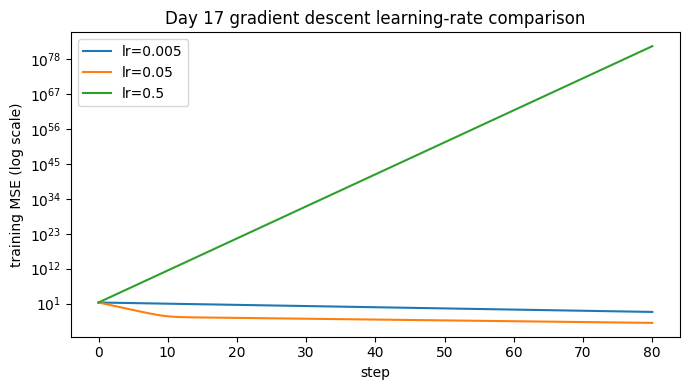

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for rate, history in histories.items():
    finite_history = history[np.isfinite(history["loss"])]
    ax.plot(finite_history["step"], finite_history["loss"], label=f"lr={rate}")
ax.set_yscale("log")
ax.set(title="Day 17 gradient descent learning-rate comparison", xlabel="step", ylabel="training MSE (log scale)")
ax.legend()
plt.tight_layout()
plt.show()


### 4. 用有限差分核对初始 `grad_w`


In [5]:
def loss_at(w, b):
    prediction = X_VALUES * w + b
    return float(np.mean((prediction - Y_VALUES) ** 2))

epsilon = 1e-6
numerical_grad_w = (
    loss_at(initial_w + epsilon, initial_b)
    - loss_at(initial_w - epsilon, initial_b)
) / (2.0 * epsilon)
print({"analytic_grad_w": initial_grad_w, "finite_difference_grad_w": numerical_grad_w})


{'analytic_grad_w': -17.0, 'finite_difference_grad_w': -17.000000003264404}


## Checks

稳定示例必须降低训练损失；大步长只作为对照，不要求通过下降断言。


In [6]:
medium_history = histories[0.05]
assert np.isclose(initial_loss, 21.0)
assert np.isclose(initial_grad_w, -17.0)
assert np.isclose(initial_grad_b, -8.0)
assert np.isclose(numerical_grad_w, initial_grad_w, rtol=1e-6, atol=1e-6)
assert np.isfinite(medium_history[["loss", "w", "b"]]).all().all()
assert medium_history.iloc[-1]["loss"] < medium_history.iloc[0]["loss"]
assert medium_history.iloc[-1]["loss"] < 0.05

print("Checks passed: analytic gradient matches finite difference; stable run lowered training loss.")


Checks passed: analytic gradient matches finite difference; stable run lowered training loss.


## Next Steps

Day 18 会把“更新一步”放进 batch/epoch 循环，并同时记录训练与验证 RMSE。这里降低的只是四个训练点上的 MSE，不证明 MLP、ESOL 或粘合剂泛化。
